In [38]:
import os                       # ilk deneme finetune yapılmış hali -> 91.44
import copy
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchvision import models, datasets, transforms
from torchvision.transforms import v2
from sklearn.metrics import precision_score, recall_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

os.makedirs('models', exist_ok=True)

# 1. VERİ ÖN İŞLEME VE ARTIRMA

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMAGE_SIZE    = 224
BATCH_SIZE    = 32
TRAIN_DIR     = 'dataset/Training'
VAL_DIR       = 'dataset/Testing'

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(degrees=15),           # rotation_range=15
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),                        # width/height_shift_range=0.1
        shear=0.1,                                   # shear_range=0.1
        scale=(0.9, 1.1)                             # zoom_range=0.1
    ),
    transforms.RandomHorizontalFlip(),               # horizontal_flip=True
    transforms.RandomVerticalFlip(),                 # vertical_flip=True => vertical flip kaldırınca gerçek hayata yaklaştı ama değişik şekilde model başarısı azaldı
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# 2. DATASET & DATALOADER

print("\n--- Eğitim Verileri Yükleniyor ---")
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
train_loader  = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,      
    pin_memory=True      
)

print("--- Doğrulama Verileri Yükleniyor ---")
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transform)
val_loader  = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

NUM_CLASSES = len(train_dataset.classes)
print(f"\nSınıf İndeks Haritası: {train_dataset.class_to_idx}")
print(f"Toplam sınıf sayısı: {NUM_CLASSES}")

# 3.EfficientNet-B0 (Ön Eğitimli)


base_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

for param in base_model.features.parameters():
    param.requires_grad = False

in_features = base_model.classifier[1].in_features 
base_model.classifier = nn.Sequential(
    nn.Linear(in_features, 256), 
    nn.ReLU(),
    nn.Dropout(0.4),              
    nn.Linear(256, NUM_CLASSES),
)

model = base_model.to(device)
print("\nModel ekran kartına taşındı")

# 4. OPTIMIZER

criterion = nn.CrossEntropyLoss()

# Sadece eğitilebilir parametreler 
optimizer = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4  
)

# 5. CALLBACK 

lr_scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.2,    
    patience=2,     
    min_lr=1e-6,     
)

best_val_loss        = float('inf')
best_model_weights   = None
epochs_no_improve    = 0
EARLY_STOP_PATIENCE  = 5

# 6. EĞİTİM 

EPOCHS = 20
history = {'train_loss': [], 'val_loss': [],
           'train_acc': [],  'val_acc': [],
           'val_precision': [], 'val_recall': []}

print("\n--- Model Eğitimi Başlıyor ---\n")

for epoch in range(EPOCHS):

    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * inputs.size(0)
        _, predicted   = outputs.max(1)
        train_correct += predicted.eq(labels).sum().item()
        train_total   += labels.size(0)

    avg_train_loss = train_loss / train_total
    avg_train_acc  = train_correct / train_total

    # Doğrulama
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

            val_loss    += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total   += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / val_total
    avg_val_acc  = val_correct / val_total

    val_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    val_recall    = recall_score(all_labels, all_preds, average='macro', zero_division=0)

    # Geçmiş sonuçlar
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_acc'].append(avg_val_acc)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
          f"Train → Loss: {avg_train_loss:.4f} | Acc: {avg_train_acc:.4f}  "
          f"Val → Loss: {avg_val_loss:.4f} | Acc: {avg_val_acc:.4f} | "
          f"LR: {current_lr:.1e}") 
    lr_scheduler.step(avg_val_loss)

    # Validasyon başarasına göre model kaydı
    if avg_val_loss < best_val_loss:
        best_val_loss      = avg_val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(best_model_weights, 'models/best_efficientnet_tumor_model.pth')
        print(f"   Model kaydedildi → val_loss: {best_val_loss:.4f}")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f" İlerleme yok ({epochs_no_improve}/{EARLY_STOP_PATIENCE})")

    # Erken durdurma
    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\n Early Stopping — En iyi val_loss: {best_val_loss:.4f}")
        break

model.load_state_dict(best_model_weights)
print("\n Eğitim tamamlandı. En iyi ağırlıklar yüklendi")

Kullanılan cihaz: cuda
   GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU

--- Eğitim Verileri Yükleniyor ---
--- Doğrulama Verileri Yükleniyor ---

Sınıf İndeks Haritası: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Toplam sınıf sayısı: 4

Model GPU'ya taşındı ✅

--- Model Eğitimi Başlıyor ---

Epoch [01/20] Train → Loss: 0.9152 | Acc: 0.7184  Val → Loss: 0.7524 | Acc: 0.7588 | LR: 1.0e-04
  ✅ Model kaydedildi → val_loss: 0.7524
Epoch [02/20] Train → Loss: 0.5349 | Acc: 0.8259  Val → Loss: 0.6738 | Acc: 0.7688 | LR: 1.0e-04
  ✅ Model kaydedildi → val_loss: 0.6738
Epoch [03/20] Train → Loss: 0.4694 | Acc: 0.8334  Val → Loss: 0.5950 | Acc: 0.8037 | LR: 1.0e-04
  ✅ Model kaydedildi → val_loss: 0.5950
Epoch [04/20] Train → Loss: 0.4413 | Acc: 0.8454  Val → Loss: 0.5902 | Acc: 0.8075 | LR: 1.0e-04
  ✅ Model kaydedildi → val_loss: 0.5902
Epoch [05/20] Train → Loss: 0.4143 | Acc: 0.8512  Val → Loss: 0.5884 | Acc: 0.8069 | LR: 1.0e-04
  ✅ Model kaydedildi → val_loss: 0.5884
Epoch 

In [44]:
# gpu vrami temizliği
import torch
import gc

gc.collect()

torch.cuda.empty_cache()

Kullanılan cihaz: cuda
   GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU

--- Eğitim Verileri Yükleniyor ---
--- Doğrulama Verileri Yükleniyor ---

Sınıf İndeks Haritası: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Toplam sınıf sayısı: 4

Model GPU'ya taşındı 

--- Model Eğitimi Başlıyor ---


--- Eğitim Sırasında Modele Giden Örnek Görseller ---


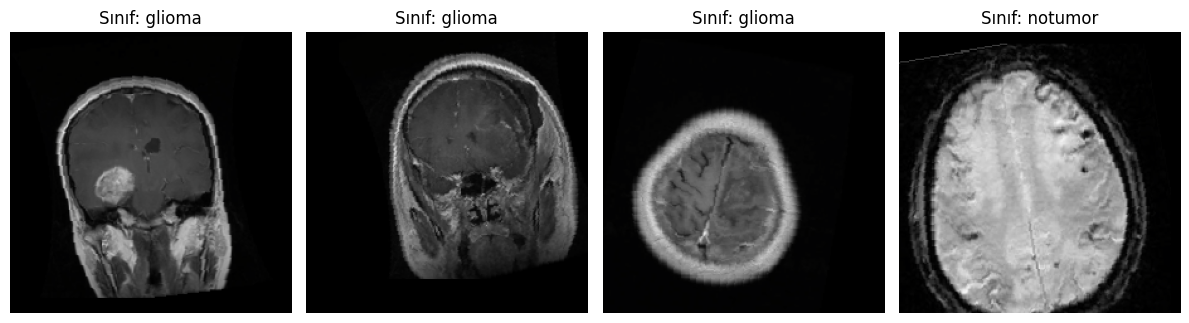

Epoch [01/30] Train → Loss: 1.0647 | Acc: 0.6837  Val → Loss: 0.9205 | Acc: 0.7288 | Precision: 0.7354 | Recall: 0.7288
  ✅ Model kaydedildi → val_loss: 0.9205
Epoch [02/30] Train → Loss: 0.7685 | Acc: 0.7996  Val → Loss: 0.8403 | Acc: 0.7725 | Precision: 0.7750 | Recall: 0.7725
  ✅ Model kaydedildi → val_loss: 0.8403
Epoch [03/30] Train → Loss: 0.7175 | Acc: 0.8225  Val → Loss: 0.9480 | Acc: 0.7913 | Precision: 0.7955 | Recall: 0.7913
  ⏳ İyileşme yok (1/5)
Epoch [04/30] Train → Loss: 0.6973 | Acc: 0.8345  Val → Loss: 0.7996 | Acc: 0.7863 | Precision: 0.7901 | Recall: 0.7862
  ✅ Model kaydedildi → val_loss: 0.7996
Epoch [05/30] Train → Loss: 0.6789 | Acc: 0.8439  Val → Loss: 0.7713 | Acc: 0.8063 | Precision: 0.8125 | Recall: 0.8062
  ✅ Model kaydedildi → val_loss: 0.7713
Epoch [06/30] Train → Loss: 0.6663 | Acc: 0.8480  Val → Loss: 1.0611 | Acc: 0.8013 | Precision: 0.8095 | Recall: 0.8012
  ⏳ İyileşme yok (1/5)
Epoch [07/30] Train → Loss: 0.6647 | Acc: 0.8496  Val → Loss: 0.7993 | Acc

In [30]:
import os
import copy
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchvision import models, datasets, transforms
from torchvision.transforms import v2
from sklearn.metrics import precision_score, recall_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

os.makedirs('models', exist_ok=True)

# 1. VERİ ÖN İŞLEME VE ARTIRMA

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMAGE_SIZE    = 224
BATCH_SIZE    = 32
TRAIN_DIR     = 'dataset/Training'
VAL_DIR       = 'dataset/Testing'

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(degrees=15),           # rotation_range=15
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),                        # width/height_shift_range=0.1
        shear=0.1,                                   # shear_range=0.1
        scale=(0.9, 1.1)                             # zoom_range=0.1
    ),
    transforms.RandomHorizontalFlip(),               # horizontal_flip=True
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# 2. DATASET & DATALOADER

print("\n--- Eğitim Verileri Yükleniyor ---")
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
train_loader  = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,      
    pin_memory=True      
)

print("--- Doğrulama Verileri Yükleniyor ---")
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transform)
val_loader  = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

NUM_CLASSES = len(train_dataset.classes)
print(f"\nSınıf İndeks Haritası: {train_dataset.class_to_idx}")
print(f"Toplam sınıf sayısı: {NUM_CLASSES}")

# 3.EfficientNet-B0 (Ön Eğitimli)


base_model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)

for param in base_model.features.parameters():
    param.requires_grad = False

in_features = base_model.classifier[1].in_features  
base_model.classifier = nn.Sequential(
    nn.Linear(in_features, 256),  
    nn.ReLU(),
    nn.Dropout(0.4),              
    nn.Linear(256, NUM_CLASSES), 
)

model = base_model.to(device)
print("\nModel GPU'ya taşındı ")

# 4. LOSS, OPTIMIZER

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Sadece eğitilebilir parametreler (dondurulmamış katmanlar)
optimizer = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4  # Keras ile aynı
)

# 5. CALLBACK 

lr_scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.2,      
    patience=2,     
    min_lr=1e-6,     
)

best_val_loss        = float('inf')
best_model_weights   = None
epochs_no_improve    = 0
EARLY_STOP_PATIENCE  = 5

# 6. EĞİTİM 

EPOCHS = 30
history = {'train_loss': [], 'val_loss': [],
           'train_acc': [],  'val_acc': [],
           'val_precision': [], 'val_recall': []}

print("\n--- Model Eğitimi Başlıyor ---\n")

import matplotlib.pyplot as plt

# Eğitim verisi görselleştirme
def show_augmented_images(dataloader, class_names, num_images=4):

    inputs, labels = next(iter(dataloader))
    
    inputs = inputs.cpu()
    labels = labels.cpu()
    
    mean = np.array(IMAGENET_MEAN).reshape((3, 1, 1))
    std = np.array(IMAGENET_STD).reshape((3, 1, 1))
    
    plt.figure(figsize=(12, 6))
    print("\n--- Eğitim Sırasında Modele Giden Örnek Görseller ---")
    
    for i in range(min(num_images, len(inputs))):
        img = inputs[i].numpy()
        # Normalizasyonu geri çevir: (img * std) + mean
        img = img * std + mean
        img = np.clip(img, 0, 1) # Değerleri [0, 1] aralığına sıkıştır
        img = np.transpose(img, (1, 2, 0)) # (C, H, W) -> (H, W, C) formatına getir
        
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(f"Sınıf: {class_names[labels[i].item()]}")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

class_names = list(train_dataset.class_to_idx.keys())
show_augmented_images(train_loader, class_names, num_images=4)
for epoch in range(EPOCHS):

    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * inputs.size(0)
        _, predicted   = outputs.max(1)
        train_correct += predicted.eq(labels).sum().item()
        train_total   += labels.size(0)

    avg_train_loss = train_loss / train_total
    avg_train_acc  = train_correct / train_total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

            val_loss    += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total   += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / val_total
    avg_val_acc  = val_correct / val_total

    val_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    val_recall    = recall_score(all_labels, all_preds, average='macro', zero_division=0)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_acc'].append(avg_val_acc)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
          f"Train → Loss: {avg_train_loss:.4f} | Acc: {avg_train_acc:.4f}  "
          f"Val → Loss: {avg_val_loss:.4f} | Acc: {avg_val_acc:.4f} | "
          f"Precision: {val_precision:.4f} | Recall: {val_recall:.4f}")

    lr_scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss      = avg_val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(best_model_weights, 'models/best_efficientnet_tumor_model.pth')
        print(f"  Model kaydedildi → val_loss: {best_val_loss:.4f}")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"   İyileşme yok ({epochs_no_improve}/{EARLY_STOP_PATIENCE})")

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\n Early Stopping — En iyi val_loss: {best_val_loss:.4f}")
        break
        
model.load_state_dict(best_model_weights)
print("\n Eğitim tamamlandı. En iyi ağırlıklar yüklendi.")

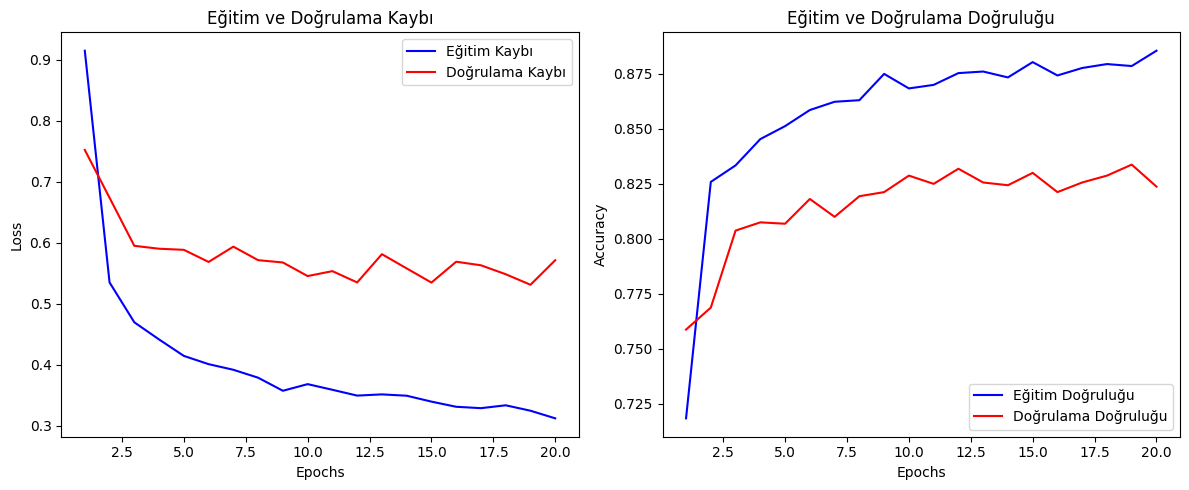

In [39]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # 1. Kayıp (Loss) Grafiği
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Eğitim Kaybı')
    plt.plot(epochs, history['val_loss'], 'r-', label='Doğrulama Kaybı')
    plt.title('Eğitim ve Doğrulama Kaybı')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # 2. Doğruluk (Accuracy) Grafiği
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Eğitim Doğruluğu')
    plt.plot(epochs, history['val_acc'], 'r-', label='Doğrulama Doğruluğu')
    plt.title('Eğitim ve Doğrulama Doğruluğu')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Grafikleri çizdir
plot_training_history(history)

In [41]:
print("\n--- İnce Ayar (Fine-Tuning) Aşaması Başlıyor ---")

for param in model.features.parameters():
    param.requires_grad = True  # Tüm katmanları açtık

# öğrenme oranı ayarı
FINE_TUNE_LR = 2e-5 
optimizer_ft = Adam(model.parameters(), lr=FINE_TUNE_LR)

best_val_loss_ft = best_val_loss 
epochs_no_improve_ft = 0
FINE_TUNE_EPOCHS = 10  

history_ft = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(FINE_TUNE_EPOCHS):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer_ft.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_ft.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        train_correct += predicted.eq(labels).sum().item()
        train_total += labels.size(0)
        
    avg_train_loss = train_loss / train_total
    avg_train_acc = train_correct / train_total
    
    # ── VALIDATION ───────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)
            
    avg_val_loss = val_loss / val_total
    avg_val_acc = val_correct / val_total
    
    print(f"FT-Epoch [{epoch+1:02d}/{FINE_TUNE_EPOCHS}] "
          f"Train Loss: {avg_train_loss:.4f} | Acc: {avg_train_acc:.4f}  "
          f"Val Loss: {avg_val_loss:.4f} | Acc: {avg_val_acc:.4f}")
          
    if avg_val_loss < best_val_loss_ft:
        best_val_loss_ft = avg_val_loss
        torch.save(model.state_dict(), 'models/best_efficientnet_tumor_model_finetuned.pth')
        print(f"  Daha iyi bir model bulundu, kaydedildi! → val_loss: {best_val_loss_ft:.4f}")
        epochs_no_improve_ft = 0
    else:
        epochs_no_improve_ft += 1
        
    if epochs_no_improve_ft >= EARLY_STOP_PATIENCE:
        print(f"\n FT Early Stopping — En iyi FT val_loss: {best_val_loss_ft:.4f}")
        break

print("\n Tüm eğitim süreçleri bitti! En optimize medikal model 'models/' altında hazır.")


--- İnce Ayar (Fine-Tuning) Aşaması Başlıyor ---
FT-Epoch [01/10] Train Loss: 0.2195 | Acc: 0.9229  Val Loss: 0.4454 | Acc: 0.8831
  Daha iyi bir model bulundu, kaydedildi! → val_loss: 0.4454
FT-Epoch [02/10] Train Loss: 0.1845 | Acc: 0.9309  Val Loss: 0.4031 | Acc: 0.8981
  Daha iyi bir model bulundu, kaydedildi! → val_loss: 0.4031
FT-Epoch [03/10] Train Loss: 0.1549 | Acc: 0.9448  Val Loss: 0.3862 | Acc: 0.9100
  Daha iyi bir model bulundu, kaydedildi! → val_loss: 0.3862
FT-Epoch [04/10] Train Loss: 0.1362 | Acc: 0.9504  Val Loss: 0.3559 | Acc: 0.9163
  Daha iyi bir model bulundu, kaydedildi! → val_loss: 0.3559
FT-Epoch [05/10] Train Loss: 0.1248 | Acc: 0.9527  Val Loss: 0.3551 | Acc: 0.9244
  Daha iyi bir model bulundu, kaydedildi! → val_loss: 0.3551
FT-Epoch [06/10] Train Loss: 0.1170 | Acc: 0.9570  Val Loss: 0.3279 | Acc: 0.9306
  Daha iyi bir model bulundu, kaydedildi! → val_loss: 0.3279
FT-Epoch [07/10] Train Loss: 0.0942 | Acc: 0.9659  Val Loss: 0.3860 | Acc: 0.9206
FT-Epoch [

--- Test Verileri Üzerinde Tahminler Yapılıyor ---


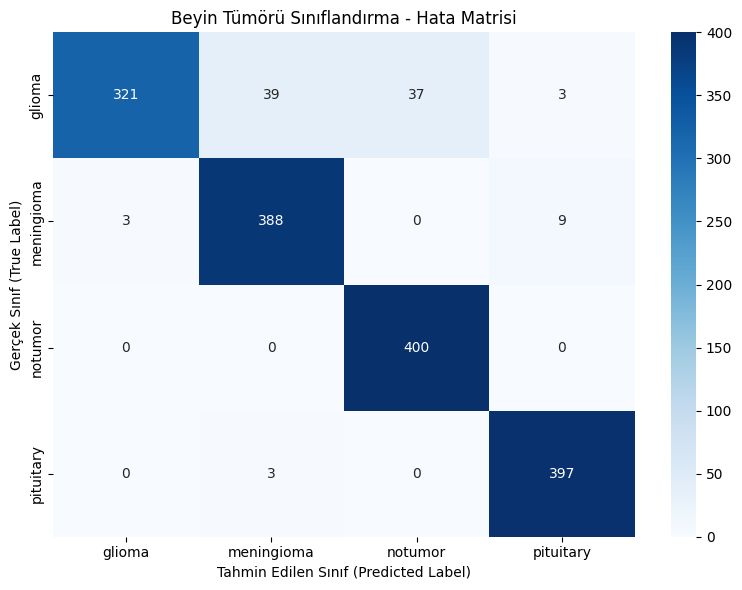


--- Detaylı Sınıflandırma Raporu ---
              precision    recall  f1-score   support

      glioma       0.99      0.80      0.89       400
  meningioma       0.90      0.97      0.93       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.97      0.99      0.98       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. TAHMİNLERİN TOPLANMASI
model.eval()
all_preds = []
all_labels = []

print("--- Test Verileri Üzerinde Tahminler Yapılıyor ---")
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 2. HATA MATRİSİNİN HESAPLANMAS
# Sınıf isimlerini dataset yapısından dinamik alıyoruz
class_names = train_dataset.classes  # ['glioma', 'meningioma', 'notumor', 'pituitary']

cm = confusion_matrix(all_labels, all_preds)

# 3. GÖRSELLEŞTİRME (HEATMAP)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,          
    fmt='d',             
    cmap='Blues',      
    xticklabels=class_names, 
    yticklabels=class_names
)

plt.title('Beyin Tümörü Sınıflandırma - Hata Matrisi')
plt.ylabel('Gerçek Sınıf (True Label)')
plt.xlabel('Tahmin Edilen Sınıf (Predicted Label)')
plt.tight_layout()
plt.show()

# 4. DETAYLI SINIFLANDIRMA RAPORU (Precision, Recall, F1-Score)
print("\n--- Detaylı Sınıflandırma Raporu ---")
print(classification_report(all_labels, all_preds, target_names=class_names))